## Problem Description - Car Price Prediction

The automobile market depends on many measurable characteristics such as engine size, horsepower, dimensions, fuel system, drivetrain, and manufacturer. The objective of this project is to predict the **price** of a car from these available attributes.

**Machine Learning Type:** Supervised Learning → Regression

#### Importing the Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

car = pd.read_csv("D:\\Internship\\ds-aiml-genai-internship\\Data\\CarPrice.csv")
car.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


#### Basic Data Overview

In [2]:
# Checking the distribution and basic shape of the dataset
print(car.shape)
display(car['price'].describe())

(205, 26)


count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

In [3]:
# checking for the data info
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [4]:
# Checking the weightage of null values.
car.isna().sum().sort_values(ascending=False)

car_ID              0
symboling           0
highwaympg          0
citympg             0
peakrpm             0
horsepower          0
compressionratio    0
stroke              0
boreratio           0
fuelsystem          0
enginesize          0
cylindernumber      0
enginetype          0
curbweight          0
carheight           0
carwidth            0
carlength           0
wheelbase           0
enginelocation      0
drivewheel          0
carbody             0
doornumber          0
aspiration          0
fueltype            0
CarName             0
price               0
dtype: int64

In [5]:
# Check for unique Value in the DataFrame.
display(car.nunique().sort_values(ascending=False))

car_ID              205
price               189
curbweight          171
CarName             147
carlength            75
horsepower           59
wheelbase            53
carheight            49
carwidth             44
enginesize           44
boreratio            38
stroke               37
compressionratio     32
highwaympg           30
citympg              29
peakrpm              23
fuelsystem            8
cylindernumber        7
enginetype            7
symboling             6
carbody               5
drivewheel            3
doornumber            2
fueltype              2
enginelocation        2
aspiration            2
dtype: int64

In [6]:
# get the summary of data
display(car.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_ID,205.0,NaN,NaN,NaN,103.0,59.322565,1.0,52.0,103.0,154.0,205.0
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
CarName,205,147,toyota corona,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fueltype,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doornumber,205,2,four,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carbody,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drivewheel,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enginelocation,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheelbase,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


#### Feature Engineering

In [7]:
# Extract the car brand from CarName and fix common spelling variations
def make_brand(series):
    brand = series.str.lower().str.split().str[0].str.replace('-', '', regex=False)
    return brand.replace({
        'maxda':'mazda', 'vokswagen':'volkswagen', 'vw':'volkswagen',
        'porcshce':'porsche', 'toyouta':'toyota', 'alfaromero':'alfa-romero'
    })

car['car_brand'] = make_brand(car['CarName'])
car[['CarName', 'car_brand']].head(10)

,CarName,car_brand
0,alfa-romero giulia,alfa-romero
1,alfa-romero stelvio,alfa-romero
2,alfa-romero Quadrifoglio,alfa-romero
3,audi 100 ls,audi
4,audi 100ls,audi
5,audi fox,audi
6,audi 100ls,audi
7,audi 5000,audi
8,audi 4000,audi
9,audi 5000s (diesel),audi


In [8]:
# Create useful numeric features from the existing columns
car['mpg_avg'] = (car['citympg'] + car['highwaympg']) / 2
car['power_to_weight'] = car['horsepower'] / car['curbweight'].replace(0, np.nan)
car['engine_power_index'] = car['enginesize'] * car['horsepower']
car['width_height_ratio'] = car['carwidth'] / car['carheight'].replace(0, np.nan)

print('New feature columns added.')

New feature columns added.


#### EXPLORATORY DATA ANALYSIS

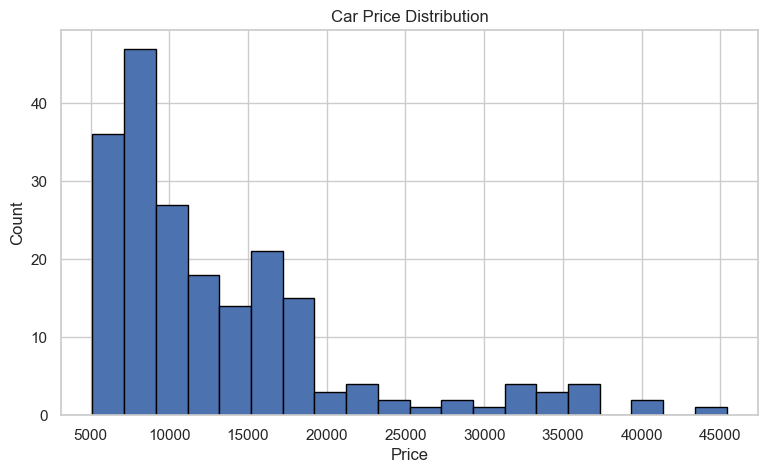

In [9]:
# box plots & histograms
plt.figure(figsize=(9,5))
plt.hist(car["price"], bins=20, edgecolor="black")
plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

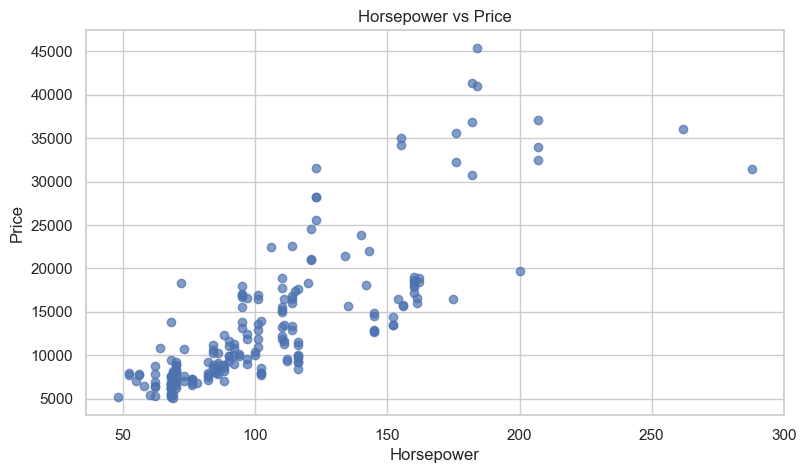

In [10]:
# Relationship between horsepower and price
plt.figure(figsize=(9,5))
plt.scatter(car["horsepower"], car["price"], alpha=0.7)
plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

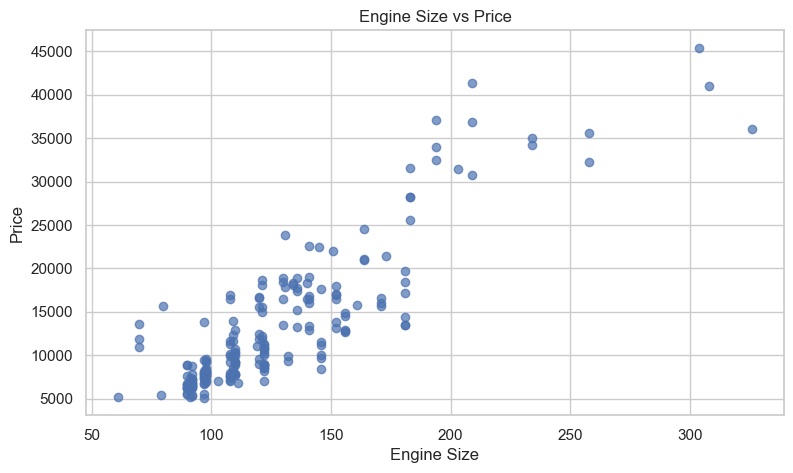

In [11]:
# Relationship between engine size and price
plt.figure(figsize=(9,5))
plt.scatter(car["enginesize"], car["price"], alpha=0.7)
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

In [12]:
# Finding the Brands with the Maximum Average Price
brand_price = car.groupby('car_brand')['price'].agg(['count','mean','median']).sort_values('mean', ascending=False)
display(brand_price.head(15))

,count,mean,median
car_brand,,,
jaguar,3,34600.000000,35550.0
buick,8,33647.000000,32892.0
porsche,5,31400.500000,32528.0
bmw,8,26118.750000,22835.0
volvo,11,18063.181818,18420.0
audi,7,17859.166714,17710.0
mercury,1,16503.000000,16503.0
alfa-romero,3,15498.333333,16500.0
peugeot,11,15489.090909,16630.0


In [13]:
# Correlation of numerical variables with price
corr = car.select_dtypes(include=np.number).corr(numeric_only=True)['price'].sort_values(ascending=False)
display(corr.head(15))

price                 1.000000
enginesize            0.874145
engine_power_index    0.865173
curbweight            0.835305
horsepower            0.808139
carwidth              0.759325
carlength             0.682920
wheelbase             0.577816
boreratio             0.553173
power_to_weight       0.533767
width_height_ratio    0.401512
carheight             0.119336
stroke                0.079443
compressionratio      0.067984
symboling            -0.079978
Name: price, dtype: float64

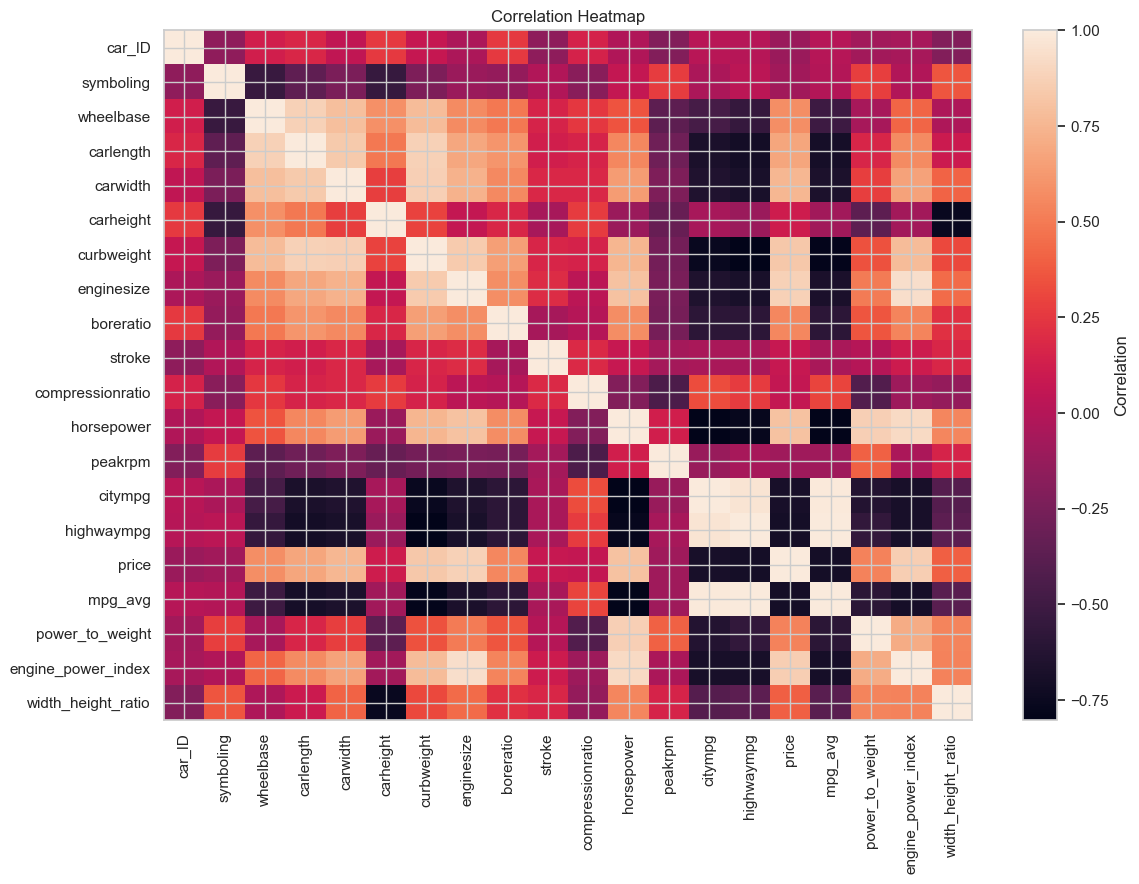

In [14]:
# Correlation heatmap
corr_matrix = car.select_dtypes(include=np.number).corr(numeric_only=True)
plt.figure(figsize=(12,9))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Data Preprocessing

In [15]:
# Remove target and raw identifiers/text, while retaining the engineered car_brand feature
model_df = car.drop(columns=['price', 'CarName', 'car_ID'])
X = model_df
y = car['price']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print('Numerical columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

Numerical columns: 18
Categorical columns: 10


In [16]:
# Stratified sampling for a regression problem using temporary target bins
price_bins = pd.qcut(y, q=5, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=price_bins
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (164, 28)
X_test : (41, 28)


In [17]:
# Build numerical and categorical preprocessing pipelines
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, num_cols),
    ('cat_pipeline', cat_pipeline, cat_cols)
])

print('Preprocessing pipeline created successfully.')

Preprocessing pipeline created successfully.


#### Build Regression Models

In [18]:
# Build Regression Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Decision Tree / Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
}

model_pipelines = {
    name: Pipeline([('preprocessor', final_pipeline), ('model', model)])
    for name, model in models.items()
}

results = []
predictions = {}
for name, model in model_pipelines.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(results_df)

,Model,MAE,RMSE,R2
0,Linear Regression,1482.213557,2022.155306,0.923570
1,Ridge Regression,1595.529601,2090.646939,0.918305
2,Extra Trees,1597.512661,2093.673105,0.918068
3,Decision Tree / Gradient Boosting,1607.597026,2122.579462,0.915790
4,Random Forest,1656.751215,2229.960253,0.907054


#### Model Evaluation

In [19]:
# Evaluation: best basic model
best_basic = results_df.iloc[0]['Model']
print('Best basic model:', best_basic)
display(results_df)

Best basic model: Linear Regression


,Model,MAE,RMSE,R2
0,Linear Regression,1482.213557,2022.155306,0.923570
1,Ridge Regression,1595.529601,2090.646939,0.918305
2,Extra Trees,1597.512661,2093.673105,0.918068
3,Decision Tree / Gradient Boosting,1607.597026,2122.579462,0.915790
4,Random Forest,1656.751215,2229.960253,0.907054


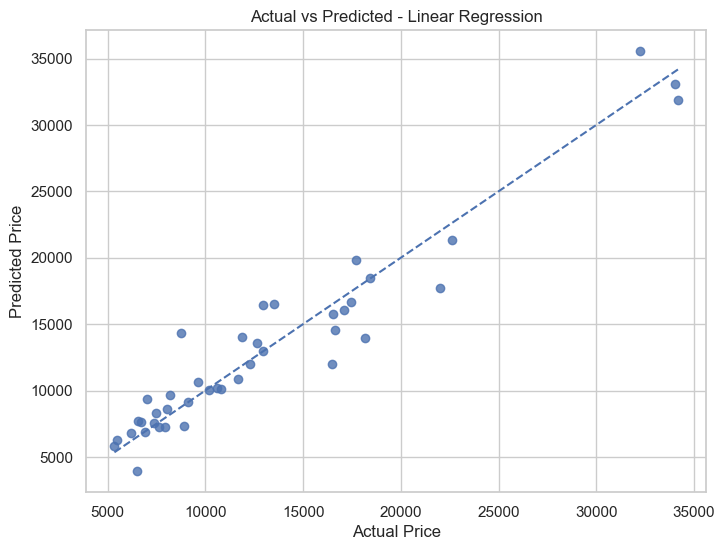

In [20]:
# Actual vs predicted price
best_pred = predictions[best_basic]
plt.figure(figsize=(8,6))
plt.scatter(y_test, best_pred, alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted - {best_basic}')
plt.show()

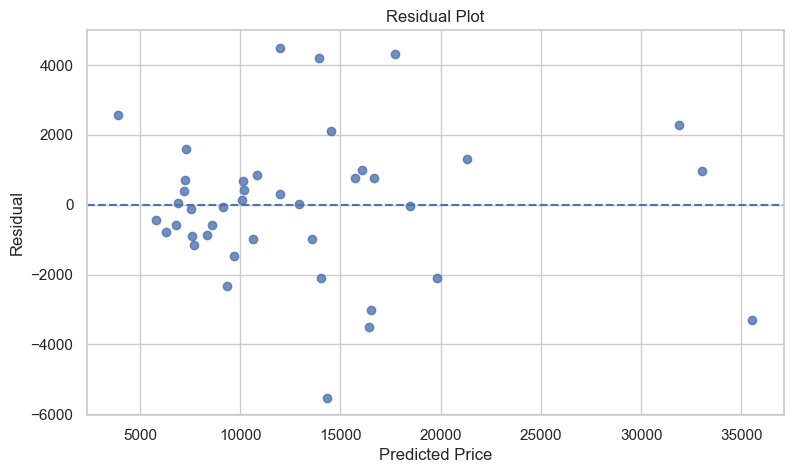

In [21]:
# Residual analysis
residuals = y_test - best_pred
plt.figure(figsize=(9,5))
plt.scatter(best_pred, residuals, alpha=0.8)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

#### Cross Validation

In [22]:
# 5-fold cross-validation for all candidate models
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, pipe in model_pipelines.items():
    scores = -cross_val_score(pipe, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    cv_rows.append({'Model': name, 'CV RMSE Mean': scores.mean(), 'CV RMSE Std': scores.std()})
cv_results = pd.DataFrame(cv_rows).sort_values('CV RMSE Mean')
display(cv_results)

,Model,CV RMSE Mean,CV RMSE Std
3,Random Forest,2037.844696,179.466259
2,Decision Tree / Gradient Boosting,2066.659327,170.364178
4,Extra Trees,2205.018979,171.644983
0,Linear Regression,2678.237675,235.137883
1,Ridge Regression,2723.367637,395.942781


#### Hyperparameter Tuning

In [23]:
# GridSearchCV for Random Forest
rf_pipe = Pipeline([
    ('preprocessor', final_pipeline),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_params = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 0.8]
}

rf_grid = GridSearchCV(
    rf_pipe, rf_params, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print('Best parameters:')
print(rf_grid.best_params_)
print('Best CV RMSE:', round(-rf_grid.best_score_, 2))

Best parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best CV RMSE: 2127.1


In [24]:
# GridSearchCV for Ridge Regression
ridge_pipe = Pipeline([
    ('preprocessor', final_pipeline),
    ('model', Ridge())
])

ridge_params = {'model__alpha': [0.1, 1, 10, 50, 100]}
ridge_grid = GridSearchCV(
    ridge_pipe, ridge_params, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

print('Best Ridge parameters:', ridge_grid.best_params_)
print('Best CV RMSE:', round(-ridge_grid.best_score_, 2))

Best Ridge parameters: {'model__alpha': 1}
Best CV RMSE: 2964.27


#### Final Model Comparison

In [25]:
# Evaluate tuned models on the untouched test set
tuned = {
    'Tuned Random Forest': rf_grid.best_estimator_,
    'Tuned Ridge': ridge_grid.best_estimator_
}

final_rows = []
for name, pipe in tuned.items():
    pred = pipe.predict(X_test)
    final_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

final_results = pd.DataFrame(final_rows).sort_values('RMSE')
display(final_results)

,Model,MAE,RMSE,R2
1,Tuned Ridge,1322.710674,1689.957857,0.946619
0,Tuned Random Forest,1639.720053,2176.737199,0.911438


#### Feature Importance

,Permutation Importance
engine_power_index,2455.123549
car_brand,1008.612855
enginesize,998.251845
curbweight,953.429807
carwidth,874.903361
enginelocation,692.179582
enginetype,569.777015
power_to_weight,506.160477
wheelbase,451.568692
cylindernumber,425.306930


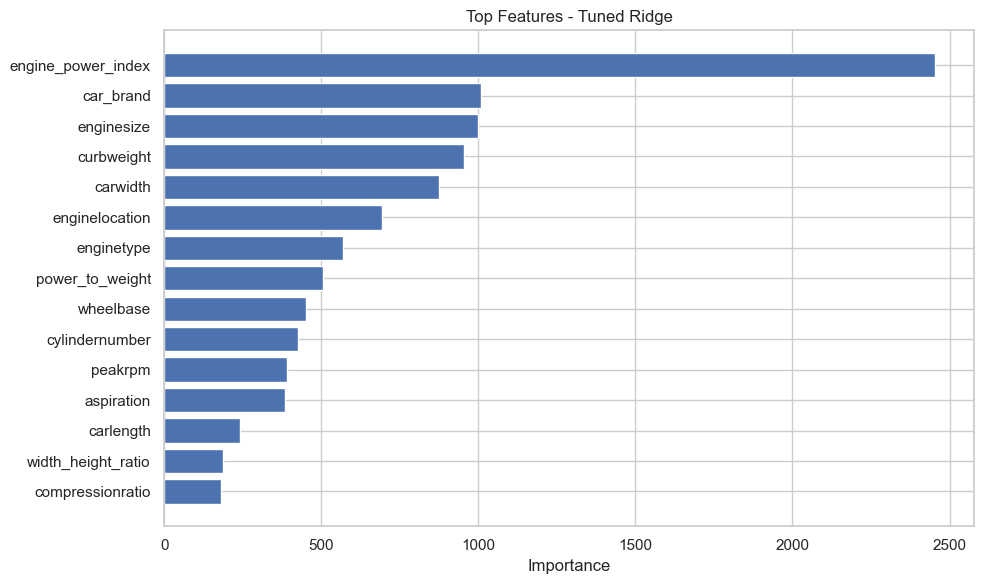

In [26]:
# Permutation importance for the best tuned model
best_tuned_name = final_results.iloc[0]['Model']
best_tuned_model = tuned[best_tuned_name]
perm = permutation_importance(
    best_tuned_model, X_test, y_test,
    scoring='neg_root_mean_squared_error', n_repeats=15,
    random_state=RANDOM_STATE, n_jobs=-1
)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)
display(importance.to_frame('Permutation Importance'))

plt.figure(figsize=(10,6))
imp_sorted = importance.sort_values()
plt.barh(imp_sorted.index, imp_sorted.values)
plt.title(f'Top Features - {best_tuned_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()